# Create File Train/Val/Test Split

In [81]:
import os 
#change current data directory to the root of the project
os.chdir("/root/birdclef-ml-framework/")

In [82]:
import pandas as pd 
import numpy as np 
import ast
import librosa 
import matplotlib.pyplot as plt
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from src.util.stats import get_label_distribution_count_for_soundscapes, get_label_distribution_count_for_train_audio, get_perch_labels
from more_itertools import powerset

In [83]:
def get_train_soundscapes_df(path):
    df = pd.read_csv(path)
    print(f"Original shape: {df.shape}")
    
    # Group by the specified columns and aggregate 'primary_label'
    df = df.groupby(['filename', 'start', 'end'], as_index=False).agg({
        'primary_label': lambda x: list(set(';'.join(x.dropna().astype(str)).split(';')))
    })
    #map back to string labels with ; seperator 
    df['primary_label'] = df['primary_label'].apply(lambda x: ';'.join(x))

    df["start"] = pd.to_timedelta(df["start"])
    df["end"] = pd.to_timedelta(df["end"])
    
    print(f"Fused shape: {df.shape}")
    return df

In [84]:
taxonomy_df = pd.read_csv("./data/birdclef_dataset/taxonomy.csv")
sample_submission_df = pd.read_csv("./data/birdclef_dataset/sample_submission.csv")
train_soundscapes_labels_df = get_train_soundscapes_df("./data/birdclef_dataset/train_soundscapes_labels.csv")


train_soundscapes_labels_df['start'] = pd.to_timedelta(train_soundscapes_labels_df['start'])
train_soundscapes_labels_df['end'] = pd.to_timedelta(train_soundscapes_labels_df['end'])
train_df = pd.read_csv("./data/birdclef_dataset/train.csv")
train_df["unique_file_id"] = train_df["filename"].apply(lambda x: x.split("/")[-1])
perch_labels = get_perch_labels()
lower_quantile = 52 #out of first visualization.ipynb

train_audio_path = "./data/birdclef_dataset/train_audio/"
train_soundscapes_path = "./data/birdclef_dataset/train_soundscapes/"

label_to_scientific_name = dict(zip(taxonomy_df["common_name"], taxonomy_df["scientific_name"]))

Original shape: (1478, 4)
Fused shape: (739, 4)
Number of species in Perch model: 14795


In [85]:
def get_file_names(audio_folder_path):
    file_names = []
    
    #recursively walk through the audio folder and its subfolders 
    for root, dirs, files in os.walk(audio_folder_path):
        for file in files:
            if file.endswith(".ogg"):
                complete_file_path = os.path.join(root, file)
                file_names.append(complete_file_path)
    return file_names

In [86]:
def get_train_audio_labels(file_path):
    #get the label for the given filename from the train_df
    #get file
    filename = os.path.basename(file_path)
    label = train_df[train_df["unique_file_id"] == filename]["primary_label"].values[0]
    secondary_labels = train_df[train_df["unique_file_id"] == filename]["secondary_labels"].values[0]
    labels = [label]
    
    if pd.notna(secondary_labels):
        #get as list 
        secondary_labels = ast.literal_eval(secondary_labels)
        labels.extend(secondary_labels)  # Add secondary labels to the list of labels
    labels = list(set(labels))  # Remove duplicates if any
    labels = [taxonomy_df[taxonomy_df["primary_label"] == label]["common_name"].values[0] for label in labels]
    return labels 

def get_train_soundscapes_labels(file_path):
    #get the label for the given filename from the train_soundscapes_labels_df
    filename = os.path.basename(file_path)
    labels = []
    print(filename)
    primary_labels_windows = train_soundscapes_labels_df[train_soundscapes_labels_df["filename"] == filename]["primary_label"]
    print("primary_labels_windows:", primary_labels_windows)
    for primary_labels_window in primary_labels_windows:
        window_labels = primary_labels_window.split(";")
        print("window_labels:", window_labels)  # Remove leading/trailing whitespace
        labels.extend(window_labels)
    labels = list(set(labels))  # Remove duplicates if any
    labels = [taxonomy_df[taxonomy_df["primary_label"] == label]["common_name"].values[0] for label in labels]
    return labels

In [87]:
rerun = False
if rerun:
    #filename; label 
    train_audio_files = get_file_names(train_audio_path)
    train_soundscapes_files = get_file_names(train_soundscapes_path)

    train_audio_dict = {filename: get_train_audio_labels(filename) for filename in train_audio_files}
    train_soundscapes_dict = {filename: get_train_soundscapes_labels(filename) for filename in train_soundscapes_files}

    #fuse the two dictionaries
    fused_dict = {**train_audio_dict, **train_soundscapes_dict}

    #df 
    all_files_df = pd.DataFrame(list(fused_dict.items()), columns=["filename", "primary_label"])
    print("Number of files with labels:", len(all_files_df))
    #filter out rows with empty labels
    all_files_df = all_files_df[all_files_df["primary_label"].map(len) > 0]
    print("Number of files with non-empty labels:", len(all_files_df))

    all_files_df.to_csv("fused_labels.csv", index=False)

else:
    all_files_df = pd.read_csv("fused_labels.csv")
    all_files_df["primary_label"] = all_files_df["primary_label"].apply(ast.literal_eval)

## Extra Rules for Labels below 1.Quantile Count

if below count of 1.quantile, files will be handled differently and the following rules apply in order 

RULES: 

- 1. if all lower_freq labels handled by perch -> test only 
- 2. is sonotype or Guaraní leaf-litter frog (soundscapes only ): 
    - try to get 1/3 train and 2/3 test for slice_count over all files and time_slices  
- 3. has unique family in taxonomy: -> test only  (marmoset,caiman,Hooded Capuchin) if possible
- 4. special case 2 froggys 
    -> Guaraní leaf-litter frog(count 8) -> like sonotype 
    -> Uruguay Harlequin Frog (count 5) -> test only 


Important:
- (after each rule apply: check whether new cases popped up in this rule (rerun vs assert) 
- (remove of file might result in other to have one file less(rerun)  or even worse if it is not even there anymore(assert)))
- (check needs to be done for special cases files and also for the rest(no new below quantile cases ))

In [88]:
special_cases_train = []
special_cases_val = []
special_cases_test = []

In [89]:
# lambda function to get_rule 
is_below_lower_quantile = lambda label_name, label_file_count: label_file_count[label_name] < lower_quantile
is_only_one_file = lambda label_name, label_file_count: label_file_count[label_name] == 1
is_low_frequency_soundscapes = lambda label_name: "sonotype" in label_name.lower()  or label_name == "Guaraní leaf-litter frog"
is_test_only_label = lambda label_name: label_name.strip() in ["Southern Spectacled Caiman", "Hooded Capuchin", "Black-tailed Marmoset", "Uruguay Harlequin Frog"]
is_perch_only = lambda scientific_names: all([scientific_name.strip().lower() in perch_labels for scientific_name in scientific_names])

In [90]:
#split all_files_df into lower_quantile_df and above_quantile_df based on the label distribution count

def get_label_file_count():
    label_file_count = get_label_distribution_count_for_soundscapes(train_soundscapes_labels_df, taxonomy_df)
    label_file_count.update(get_label_distribution_count_for_train_audio(train_df, taxonomy_df))
    return label_file_count
                         
def get_below_lower_quantile_df(all_files_df):
    label_file_count = get_label_file_count()
    all_files_df["below_lower_quantile"] = all_files_df["primary_label"].apply(lambda label_list: any(is_below_lower_quantile(label, label_file_count) for label in label_list))
    return all_files_df[all_files_df["below_lower_quantile"] == True]

#split all_files_df into lower_quantile_df and above_quantile_df based on the rules via index
lower_quantile_df = get_below_lower_quantile_df(all_files_df)
above_quantile_df = all_files_df[~all_files_df.index.isin(lower_quantile_df.index)]
label_file_count = get_label_file_count()

only_one_file_labels = [label for label, count in label_file_count.items() if count == 1]
print("Labels with only one file:", only_one_file_labels)

assert len(lower_quantile_df) + len(above_quantile_df) == len(all_files_df)




Labels with only one file: ['Southern Spectacled Caiman', 'Insect sonotype20', 'Insect sonotype18', 'Insect sonotype16', 'Insect sonotype15', 'Hooded Capuchin', 'Insect sonotype09', 'Insect sonotype12', 'Chiasmocleis mehelyi', 'Insect sonotype14', 'Insect sonotype02', 'Central Dwarf Frog', 'Waxy Monkey Tree Frog']


#### Perch Rule

In [91]:
print("Before Perch Rule", len(lower_quantile_df))
for lower_quantile_df_index, row in lower_quantile_df.copy(deep=True).iterrows():
    label_list = row["primary_label"]
    #map to scientific name 
    scientific_names = [label_to_scientific_name.get(label, label) for label in label_list]
    if is_perch_only(scientific_names):
            special_cases_test.append(row["filename"])
            for label in label_list:
                label_file_count[label] -= 1  # Decrement the count for this label
            lower_quantile_df = lower_quantile_df.drop(lower_quantile_df_index)  # Remove this file from lower_quantile_df
print("After Perch Rule", len(lower_quantile_df))

Before Perch Rule 862
After Perch Rule 37


#### Catch other low frequency labels that only have their own files 

In [92]:
lonely_labels = list(set([row["primary_label"][0] for _, row in lower_quantile_df.iterrows() if len(row["primary_label"]) == 1]))

for lonely_label in lonely_labels:
    #check if the label has only its own files in the lower_quantile_df
    for lower_quantile_df_index, row in lower_quantile_df.copy(deep=True).iterrows():
        if lonely_label in row["primary_label"]:
            #check if the file has only this label
            if len(row["primary_label"]) == 1 and (is_test_only_label(lonely_label)):
                special_cases_test.append(row["filename"])
                label_file_count[lonely_label] -= 1  # Decrement the count for this label
                lower_quantile_df = lower_quantile_df.drop(lower_quantile_df_index)  # Remove this file from lower_quantile_df
print("After Lonely Label Rule", len(lower_quantile_df))

After Lonely Label Rule 23


In [93]:
#assert that all other files are soundscape files 
for lower_quantile_df_index, row in lower_quantile_df.iterrows():
    filename = row["filename"]
    if "train_soundscapes" not in filename:
        raise ValueError(f"File {filename} is not a soundscape file but is in the lower_quantile_df.")
        
    


### Catch low frequency without sonotypes 


In [94]:

for lower_quantile_df_index, row in lower_quantile_df.copy(deep=True).iterrows():
    label_list = row["primary_label"]
    
    has_label_of_sonotype = [label for label in label_list if "sonotype" in label.lower()]
    if has_label_of_sonotype:
        continue

    for label in label_list:
        if is_test_only_label(label):
            special_cases_test.append(row["filename"])
            for label in label_list:
                print(label)
                assert not "sonotype" in label.lower()  # Ensure that low frequency sonotypes are not included in this rule
                label_file_count[label] -= 1  # Decrement the count for this label
            lower_quantile_df = lower_quantile_df.drop(lower_quantile_df_index)  # Remove this file from lower_quantile_df
            continue

print("After other is_test_only_label", len(lower_quantile_df))

Thrush-like Wren
Great Kiskadee
Hooded Capuchin
Chaco Chachalaca
Plush-crested Jay
After other is_test_only_label 22


In [95]:
#assert that all other files are soundscape files 
for lower_quantile_df_index, row in lower_quantile_df.iterrows():
    filename = row["filename"]
    if not any(is_low_frequency_soundscapes(label) for label in row["primary_label"]):
        raise ValueError(f"File {filename} does not contain low frequency soundscape labels but is in the lower_quantile_df.")
        

In [96]:
#plot label_count per file before splitting the files in half 
def get_label_time_stamp_count_dict(df,start="00:00:00", end="00:01:00",key_filter_func=None): 
    start = pd.to_timedelta(start)
    end = pd.to_timedelta(end)
    
    label_time_stamp_count_dict = {}
    
    for _, row in df.iterrows():
        file_name = row["filename"].split("/")[-1]
        file_time_stamps_df = train_soundscapes_labels_df[train_soundscapes_labels_df["filename"] == file_name]
        for time_stamp_row in file_time_stamps_df.itertuples():
            time_stamp_primary_labels = time_stamp_row.primary_label.split(";")
            if not (time_stamp_row.start >= start and time_stamp_row.end <= end):
                continue

            for label in time_stamp_primary_labels:
                if label not in label_time_stamp_count_dict:
                    label_time_stamp_count_dict[label] = 0
                if label in time_stamp_primary_labels:
                    label_time_stamp_count_dict[label] += 1
    
    #map keys back to common names
    label_time_stamp_count_dict = {taxonomy_df[taxonomy_df["primary_label"] == label]["common_name"].values[0]: count for label, count in label_time_stamp_count_dict.items()}
    
    # filter keys based on key_filter_func if provided
    if key_filter_func is not None:
        label_time_stamp_count_dict = {label: count for label, count in label_time_stamp_count_dict.items() if key_filter_func(label)}
    return label_time_stamp_count_dict

potential_time_slices = [("00:00:00", f"00:00:{str(i).zfill(2)}") for i in range(5,60,5)]

In [97]:
# showcase simple slicing for every file 
# best case for split 1/3 train and 2/3 test 

for _, end in potential_time_slices:
    print(f"\nTime slice: {end}")
    print("Train: ", get_label_time_stamp_count_dict(lower_quantile_df, end=end, key_filter_func = is_low_frequency_soundscapes))
    print("Test: ", get_label_time_stamp_count_dict(lower_quantile_df, start=end, key_filter_func = is_low_frequency_soundscapes))


Time slice: 00:00:05
Train:  {'Insect sonotype07': 4, 'Insect sonotype03': 3, 'Insect sonotype01': 2, 'Insect sonotype24': 2, 'Insect sonotype12': 1, 'Insect sonotype11': 3, 'Insect sonotype22': 2, 'Insect sonotype23': 2, 'Insect sonotype25': 7, 'Insect sonotype13': 3, 'Guaraní leaf-litter frog': 6, 'Insect sonotype06': 1, 'Insect sonotype14': 1, 'Insect sonotype02': 1, 'Insect sonotype10': 2, 'Insect sonotype04': 2, 'Insect sonotype17': 3, 'Insect sonotype20': 1, 'Insect sonotype08': 1, 'Insect sonotype18': 1, 'Insect sonotype16': 1, 'Insect sonotype15': 1}
Test:  {'Insect sonotype07': 44, 'Insect sonotype03': 30, 'Insect sonotype01': 21, 'Insect sonotype24': 22, 'Insect sonotype12': 4, 'Insect sonotype11': 33, 'Insect sonotype09': 6, 'Insect sonotype04': 15, 'Insect sonotype22': 22, 'Insect sonotype23': 22, 'Insect sonotype21': 22, 'Insect sonotype25': 77, 'Insect sonotype13': 33, 'Guaraní leaf-litter frog': 73, 'Insect sonotype06': 17, 'Insect sonotype14': 11, 'Insect sonotype02': 

In [98]:

label_time_stamp_count_dict = get_label_time_stamp_count_dict(lower_quantile_df)
#remove labels that are not is_low_frequency_soundscapes
label_time_stamp_count_dict = {label: count for label, count in label_time_stamp_count_dict.items() if is_low_frequency_soundscapes(label)}
print("Label time stamp count before splitting:", label_time_stamp_count_dict)

max_key = max([count for label, count in label_time_stamp_count_dict.items()]) +1 
#sort lower_quantile_df by the sum of label_time_stamp_count_dict values for each file
lower_quantile_df["urgency"] = lower_quantile_df["primary_label"].apply(lambda label_list: min(label_time_stamp_count_dict.get(label, max_key) if is_low_frequency_soundscapes(label) else max_key for label in label_list))

lower_quantile_df = lower_quantile_df.sort_values(by="urgency", ascending=True)


train_label_time_stamp_count = dict.fromkeys(label_time_stamp_count_dict.keys(), 0)
test_label_time_stamp_count = dict.fromkeys(label_time_stamp_count_dict.keys(), 0)
    

Label time stamp count before splitting: {'Insect sonotype07': 48, 'Insect sonotype03': 33, 'Insect sonotype01': 23, 'Insect sonotype24': 24, 'Insect sonotype12': 5, 'Insect sonotype11': 36, 'Insect sonotype09': 6, 'Insect sonotype04': 17, 'Insect sonotype22': 24, 'Insect sonotype23': 24, 'Insect sonotype25': 84, 'Insect sonotype13': 36, 'Insect sonotype21': 22, 'Guaraní leaf-litter frog': 79, 'Insect sonotype06': 18, 'Insect sonotype14': 12, 'Insect sonotype02': 7, 'Insect sonotype10': 33, 'Insect sonotype08': 17, 'Insect sonotype17': 43, 'Insect sonotype05': 3, 'Insect sonotype20': 12, 'Insect sonotype19': 5, 'Insect sonotype18': 12, 'Insect sonotype16': 12, 'Insect sonotype15': 12}


In [99]:
#precompute soundscapes_time_stamps_positions
def get_soundscapes_time_stamps_positions():
    time_stamp_starts = [f"00:00:{str(i).zfill(2)}" for i in range(0,60,5)]
    soundscapes_time_stamps_positions = {label: {} for label, count in label_time_stamp_count_dict.items()} # label: {file: slice_point}
    for label, count in sorted(label_time_stamp_count_dict.items(),key=lambda item: item[1]):

        files = lower_quantile_df[lower_quantile_df["primary_label"].apply(lambda label_list: label in label_list)]["filename"].tolist() 
        primary_label = taxonomy_df[taxonomy_df["common_name"] == label]["primary_label"].values[0]

        for file in files:
            soundscapes_time_stamps_positions[label][file] = []

        for file in files:
            file_time_stamps_df = train_soundscapes_labels_df[train_soundscapes_labels_df["filename"] == file.split("/")[-1]]
            count_for_file = 0
            for slice_idx, start in enumerate(time_stamp_starts):
                is_in_slice = file_time_stamps_df[(file_time_stamps_df["start"] == start)].apply(lambda row: primary_label in row["primary_label"].split(";"), axis=1).any()
                if bool(is_in_slice): 
                    soundscapes_time_stamps_positions[label][file].append(slice_idx)



    return soundscapes_time_stamps_positions


def transpose_dict_to_file(soundscapes_time_stamps_positions):
    file_time_stamps_positions = {}
    for label, file_positions in soundscapes_time_stamps_positions.items():
        has_one_file_only = len(list(file_positions.keys())) == 1
        for file, positions in file_positions.items():
            if file not in file_time_stamps_positions:
                file_time_stamps_positions[file] = {"labels": {}, "only_one": has_one_file_only}
            file_time_stamps_positions[file]["labels"][label] = positions
            if "only_one" not in file_time_stamps_positions[file]:  # Only set "only_one" if it hasn't been set before
                file_time_stamps_positions[file]["only_one"] = has_one_file_only  
            else: 
                file_time_stamps_positions[file]["only_one"] = file_time_stamps_positions[file]["only_one"] or has_one_file_only  # Update "only_one" to be True only if all labels for this file have one file only
    return file_time_stamps_positions




In [100]:
# remaining sonotypes split 
# best case for split 1/3 train and 2/3 test 

# if label has only one file it must be sliced 
# if not it shouldnt

#things to try: 
# split per every file on 1/3 to get all labels in test 

def find_optimal_time_slice_for_label(label,total_count,file, train_ratio=0.33):
    #get all files that contain this label 
    file_df = lower_quantile_df[lower_quantile_df["filename"] == file.split("/")[-1]]

    print(file_df)

def find_two_third_test_slice_for_every_label(file): 
    

    min_slice_idxs = []
    for label, positions in per_file_time_stamps_positions_dict[file]["labels"].items():
        if not (label in only_one_file_labels):
            continue
        min_slice_idxs.append(positions[int(len(positions)//3)-1])
    print(f"File: {file}, min_slice_idxs: {min_slice_idxs}")



    return max(min_slice_idxs)  


def get_train_test_files_for_label(files, desired_label, train_ratio=0.33):

    all_labels_in_files = set()
    for file in files:
        all_labels_in_files.update(per_file_time_stamps_positions_dict[file]["labels"].keys())
    
    label_counts_in_files = {label: 0 for label in all_labels_in_files}
    for file in files:
        for label in per_file_time_stamps_positions_dict[file]["labels"].keys():
            label_counts_in_files[label] += len(per_file_time_stamps_positions_dict[file]["labels"][label])

    all_sets = powerset(files)

    backup_splits = []

    #find ratio
    while train_ratio < 1.0:

        for potential_train_files in all_sets:
            potential_train_distribution = {label: 0 for label in label_time_stamp_count_dict.keys()}
            potential_test_distribution = {label: 0 for label in label_time_stamp_count_dict.keys()}
            potential_test_files = set(files) - set(potential_train_files)

            #update potential_train_distribution and potential_test_distribution based on the files in potential_train_files and potential_test_files
            for file in potential_train_files:
                for label in per_file_time_stamps_positions_dict[file]["labels"].keys():
                    potential_train_distribution[label] += len(per_file_time_stamps_positions_dict[file]["labels"][label])
            for file in potential_test_files:
                for label in per_file_time_stamps_positions_dict[file]["labels"].keys():
                    potential_test_distribution[label] += len(per_file_time_stamps_positions_dict[file]["labels"][label])

            if all(potential_test_distribution[label] >= label_counts_in_files[label] * (1 - train_ratio)  for label in label_counts_in_files.keys()):
                return potential_train_files, potential_test_files
            
            achieved_test_ratio_for_desired_label = potential_test_distribution[desired_label] >= label_counts_in_files[desired_label] * (1 - train_ratio)
            all_labels_filled = all(potential_test_distribution[label] >= 1 and potential_train_distribution[label] >= 1 for label in label_counts_in_files.keys())
            if achieved_train_ratio_for_desired_label and achieved_test_ratio_for_desired_label and all_labels_filled:

                backup_splits.append((potential_train_files, potential_test_files))
        train_ratio = train_ratio + 0.05

    print(backup_splits)
    return backup_splits[0][0], backup_splits[0][1]


per_label_time_stamps_positions_dict = get_soundscapes_time_stamps_positions()
per_file_time_stamps_positions_dict = transpose_dict_to_file(per_label_time_stamps_positions_dict)

# ignore     
print("Before splitting: distribution", label_time_stamp_count_dict)
print("Before splitting: number of files", len(per_file_time_stamps_positions_dict))        
# split all files first that dont have file_label_count of 1 for every label
for label, count in sorted(label_time_stamp_count_dict.items(),key=lambda item: item[1]):

    files = list(per_label_time_stamps_positions_dict[label].keys())


    if is_only_one_file(label,label_file_count):
        continue 

    else: 
        splitable_files = [file for file in files if file in per_file_time_stamps_positions_dict.keys()] #check if file stll exist 
        splitable_files = [file for file in splitable_files if not per_file_time_stamps_positions_dict[file]["only_one"]] # check if file is not only one file for its labels
        if len(splitable_files) == 0:
            continue
        train_files, test_files = get_train_test_files_for_label(splitable_files, desired_label=label)

        #update label_time_stamp_count_dict based on the split
        for file in train_files:
            for label in per_file_time_stamps_positions_dict[file]["labels"].keys():
                label_time_stamp_count_dict[label] -= len(per_file_time_stamps_positions_dict[file]["labels"][label])
                train_label_time_stamp_count[label] += len(per_file_time_stamps_positions_dict[file]["labels"][label])
            per_file_time_stamps_positions_dict.pop(file)  # Remove the file from consideration in future splits
        for file in test_files:
            for label in per_file_time_stamps_positions_dict[file]["labels"].keys():
                label_time_stamp_count_dict[label] -= len(per_file_time_stamps_positions_dict[file]["labels"][label])
                test_label_time_stamp_count[label] += len(per_file_time_stamps_positions_dict[file]["labels"][label])
            per_file_time_stamps_positions_dict.pop(file)  # Remove the file from consideration in future splits

print("After splitting labels with more than one file: distribution", label_time_stamp_count_dict)
print("Remaining files after splitting labels with more than one file:", len(per_file_time_stamps_positions_dict))        

for file, values in per_file_time_stamps_positions_dict.items():
    split_point = find_two_third_test_slice_for_every_label(file)

    #update label_time_stamp_count_dict based on the split
    for label in values["labels"].keys():
        positions = values["labels"][label]
        count_in_train = sum(1 for position in positions if position < split_point)
        count_in_test = sum(1 for position in positions if position >= split_point)
        train_label_time_stamp_count[label] += count_in_train
        test_label_time_stamp_count[label] += count_in_test
        label_time_stamp_count_dict[label] -= (count_in_train + count_in_test)  # Remove the count for this label as it has been split


#loop over remaining files and split them based on the find_two_third_test_slice_for_every_label function 
print("Train label time stamp count:", train_label_time_stamp_count)
print("Test label time stamp count:", test_label_time_stamp_count)
print("Remaining label time stamp count (should be 0):", label_time_stamp_count_dict)

Before splitting: distribution {'Insect sonotype07': 48, 'Insect sonotype03': 33, 'Insect sonotype01': 23, 'Insect sonotype24': 24, 'Insect sonotype12': 5, 'Insect sonotype11': 36, 'Insect sonotype09': 6, 'Insect sonotype04': 17, 'Insect sonotype22': 24, 'Insect sonotype23': 24, 'Insect sonotype25': 84, 'Insect sonotype13': 36, 'Insect sonotype21': 22, 'Guaraní leaf-litter frog': 79, 'Insect sonotype06': 18, 'Insect sonotype14': 12, 'Insect sonotype02': 7, 'Insect sonotype10': 33, 'Insect sonotype08': 17, 'Insect sonotype17': 43, 'Insect sonotype05': 3, 'Insect sonotype20': 12, 'Insect sonotype19': 5, 'Insect sonotype18': 12, 'Insect sonotype16': 12, 'Insect sonotype15': 12}
Before splitting: number of files 22
After splitting labels with more than one file: distribution {'Insect sonotype07': 0, 'Insect sonotype03': 21, 'Insect sonotype01': 11, 'Insect sonotype24': 12, 'Insect sonotype12': 5, 'Insect sonotype11': 24, 'Insect sonotype09': 6, 'Insect sonotype04': 1, 'Insect sonotype22': 

In [101]:
#

## Multilabel Stratified Split on the rest of the Data

In [102]:
# perform multilabel split to have every unique label in the train and validation set
train_size = 0.7 
val_size = 0.15
test_size = 0.15

In [103]:
#class mapping 
class_mapping = {label: idx for idx, label in enumerate(sorted(taxonomy_df['primary_label'].unique()))}

In [104]:
print("class_mapping:", class_mapping)

class_mapping: {'1161364': 0, '116570': 1, '1176823': 2, '1491113': 3, '1595929': 4, '209233': 5, '22930': 6, '22956': 7, '22961': 8, '22967': 9, '22973': 10, '22983': 11, '22985': 12, '23150': 13, '23154': 14, '23158': 15, '23176': 16, '23724': 17, '24279': 18, '24285': 19, '24287': 20, '24321': 21, '244024': 22, '25073': 23, '25092': 24, '25214': 25, '326272': 26, '41970': 27, '43435': 28, '47144': 29, '47158son01': 30, '47158son02': 31, '47158son03': 32, '47158son04': 33, '47158son05': 34, '47158son06': 35, '47158son07': 36, '47158son08': 37, '47158son09': 38, '47158son10': 39, '47158son11': 40, '47158son12': 41, '47158son13': 42, '47158son14': 43, '47158son15': 44, '47158son16': 45, '47158son17': 46, '47158son18': 47, '47158son19': 48, '47158son20': 49, '47158son21': 50, '47158son22': 51, '47158son23': 52, '47158son24': 53, '47158son25': 54, '476521': 55, '516975': 56, '517063': 57, '555123': 58, '555145': 59, '555146': 60, '64898': 61, '65377': 62, '65380': 63, '66971': 64, '67107

In [105]:

random_state = 42
np.random.seed(random_state)

# Let's target a 70% Train, 15% Val, 15% Test split.
X = np.array([i for i in range(len(all_files_df))])  # Just an index array for splitting
y = np.array([[0] * len(class_mapping) for _ in range(len(all_files_df))])  # one hot vectors of labels for each sample
for idx, labels in enumerate(all_files_df["labels"]):
    for label in labels:
        label_idx = class_mapping[label]
        y[idx][label_idx] = 1 

# ---------------------------------------------------------
# Step 1: Split into Temp (70%) and Test (30%)
msss1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)

for temp_index, test_index in msss1.split(X, y):
    X_temp, X_test = X[temp_index], X[test_index]
    y_temp, y_test = y[temp_index], y[test_index]

# ---------------------------------------------------------
# Step 2: Split Temp into Train (70%) and Val (30%)
#recalculate percentages for train and val based on the new temp size
val_size = val_size / (train_size + val_size)  # Adjust val_size to
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)

for train_index, val_index in msss2.split(X_temp, y_temp):
    X_train, X_val = X_temp[train_index], X_temp[val_index]
    y_train, y_val = y_temp[train_index], y_temp[val_index]

# ---------------------------------------------------------
# Verification
# ---------------------------------------------------------
print(f"Total samples: {len(X)}")
print(f"Train samples: {len(X_train)}")
print(f"Val samples:   {len(X_val)}")
print(f"Test samples:  {len(X_test)}\n")

print("Label distributions (sum of positive classes):")
print(f"Original: {y.sum(axis=0)}")
print(f"Train:    {y_train.sum(axis=0)}")
print(f"Val:      {y_val.sum(axis=0)}")
print(f"Test:     {y_test.sum(axis=0)}")

KeyError: 'labels'

In [ ]:
#create csvs based on x_train, x_val, x_test
train_df = all_files_df.iloc[X_train]
val_df = all_files_df.iloc[X_val]
test_df = all_files_df.iloc[X_test]

train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

Total samples: 35615
Train samples: 24945
Val samples:   5394
Test samples:  5276

Label distributions (sum of positive classes):
Original: [  11    9   12    8    5    2    6   32    9   22   84   10    6    1
    5   43    4    1   69   19   12   21  181    1   32    3   33   21
   16   48    2    1    3    3    2    2    4    2    1    4    3    1
    3    1    1    1    4    1    2    1    2    2    2    2    7    3
    6   40    3    9   40    3   47   53   23   18    7    2    5   11
    3    7  140  142   54  342  616  550  304  230  505   66  216  113
   59  169   73  571  576  148  474  222  134  246  212  239  137  173
  284  394  145   42  513  565  392  334   84   23  217  387  120  600
   68  285   92  275  139  121  137  513  144  567  246 1106   75  224
  477  276   98  449  117  565   72  160  131   30  423  377  109  130
  115   78   77  315   20   15  455   89  247  495  326   86  303  154
  334  428  192   38  205   95  100  286  106  201  142  233  194  251
  106  5

In [ ]:
print(train_df.shape[0], "samples in train set")
print(val_df.shape[0], "samples in validation set")
print(test_df.shape[0], "samples in test set")

print(train_df.head(5))
print(val_df.head(5))
print(test_df.head(5))

24234 samples in train set
6105 samples in validation set
5276 samples in test set
                                    filename    labels
0   ./data/train_audio/555145/iNat139216.ogg  [555145]
3   ./data/train_audio/555145/iNat937677.ogg  [555145]
4  ./data/train_audio/555145/iNat1242826.ogg  [555145]
5   ./data/train_audio/555145/iNat179807.ogg  [555145]
7     ./data/train_audio/555145/XC903862.ogg  [555145]
                                     filename           labels
1   ./data/train_audio/555145/iNat1421758.ogg         [555145]
6      ./data/train_audio/555145/XC929078.ogg  [555145, 24287]
15  ./data/train_audio/1176823/iNat188986.ogg        [1176823]
19  ./data/train_audio/1176823/iNat829107.ogg        [1176823]
22  ./data/train_audio/bbwduc/iNat1593878.ogg         [bbwduc]
                                      filename     labels
2     ./data/train_audio/555145/iNat172617.ogg   [555145]
9   ./data/train_audio/1176823/iNat1269019.ogg  [1176823]
18  ./data/train_audio/1176823/iNat

In [ ]:
def get_label_distribution_count(df):
    #get label distribution 
    df_labels_count = {}
    for row in df.itertuples():
        labels = row.labels

        for label in labels:
            if label in df_labels_count:
                df_labels_count[label] += 1
            else:
                df_labels_count[label] = 1
    return df_labels_count

def plot_label_distribution_count(df_labels_count):
    print("Number of animals labeled in train soundscapes labels: {}".format(len(df_labels_count)))
    #print("Label distribution in train soundscapes labels:")
    #for label, count in df_labels_count.items():
    #    print(f"{label}: {count}")
    #plot label distribution in train soundscapes labels
    plt.figure(figsize=(10,5))
    plt.bar(df_labels_count.keys(), df_labels_count.values())
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.title("Label Distribution in Labels")
    plt.xticks(rotation=45)

24945 samples in train set
5394 samples in validation set
5276 samples in test set
                                            filename           labels
0  ./data/birdclef_dataset/train_audio/555145/iNa...         [555145]
1  ./data/birdclef_dataset/train_audio/555145/iNa...         [555145]
4  ./data/birdclef_dataset/train_audio/555145/iNa...         [555145]
5  ./data/birdclef_dataset/train_audio/555145/iNa...         [555145]
6  ./data/birdclef_dataset/train_audio/555145/XC9...  [555145, 24287]
                                             filename     labels
3   ./data/birdclef_dataset/train_audio/555145/iNa...   [555145]
11  ./data/birdclef_dataset/train_audio/1176823/iN...  [1176823]
13  ./data/birdclef_dataset/train_audio/1176823/iN...  [1176823]
29  ./data/birdclef_dataset/train_audio/bbwduc/iNa...   [bbwduc]
33  ./data/birdclef_dataset/train_audio/bbwduc/XC2...   [bbwduc]
                                             filename     labels
2   ./data/birdclef_dataset/train_audio/55


Train Set:
Number of animals labeled in train soundscapes labels: 232

Validation Set:
Number of animals labeled in train soundscapes labels: 217

Test Set:
Number of animals labeled in train soundscapes labels: 202


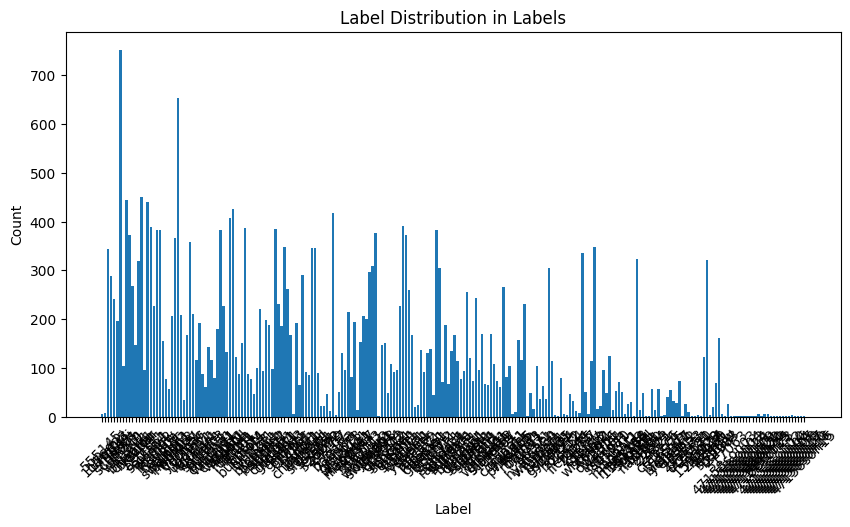

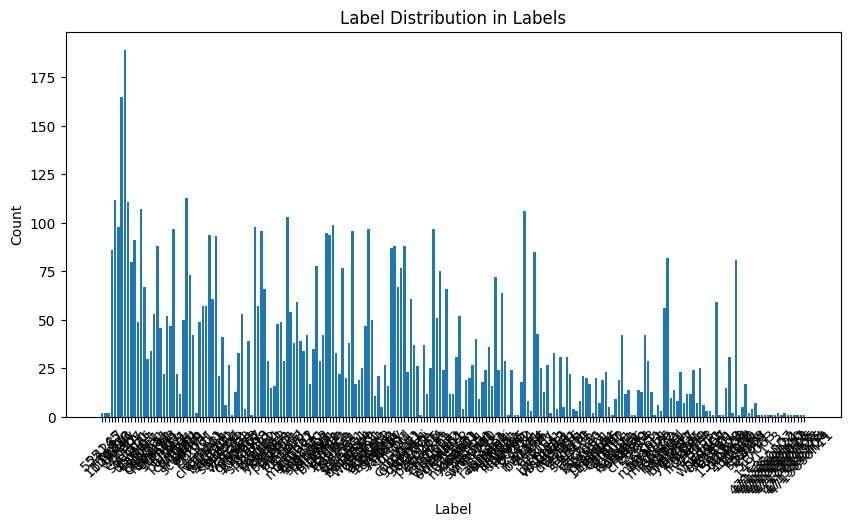

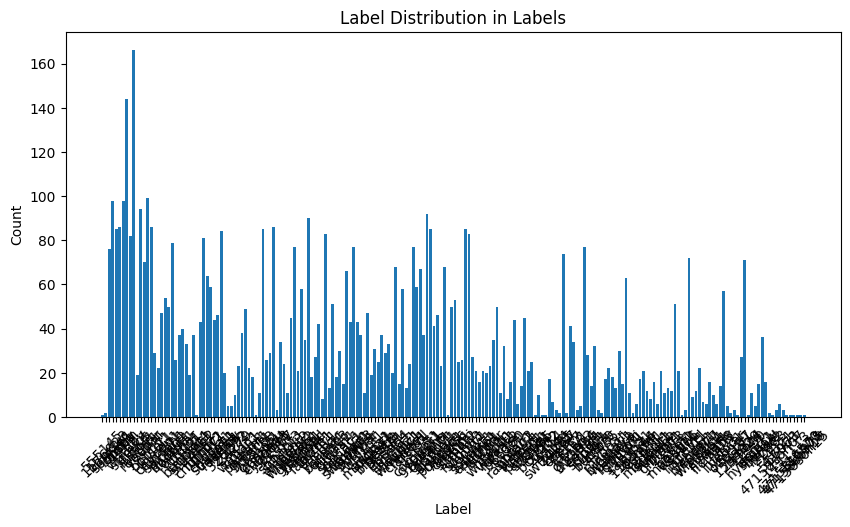

In [ ]:
for df, name in zip([train_df, val_df, test_df], ["Train", "Validation", "Test"]):
    print(f"\n{name} Set:")
    df_labels_count = get_label_distribution_count(df)
    plot_label_distribution_count(df_labels_count)